In [ ]:
# notebook for building CNN with cats & dogs dataset

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

### Importing the raw cat and dog images

In [14]:
# importing the data (cat and dog images)
from pathlib import Path
# remove common hidden/non-image files that cause TF decode errors (desktop.ini, macOS '._' sidecars)
data_dir = Path("../data/cats_dogs")
for f in data_dir.rglob('desktop.ini'):
    try:
        f.unlink()
    except Exception:
        pass
for f in data_dir.rglob('._*'):
    try:
        f.unlink()
    except Exception:
        pass

data_dir = "../data/cats_dogs"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [3]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [15]:
# View labels from the first training batch
# remove invalid files from the dataset directory before running this code, otherwise it will throw an error

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


In [16]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


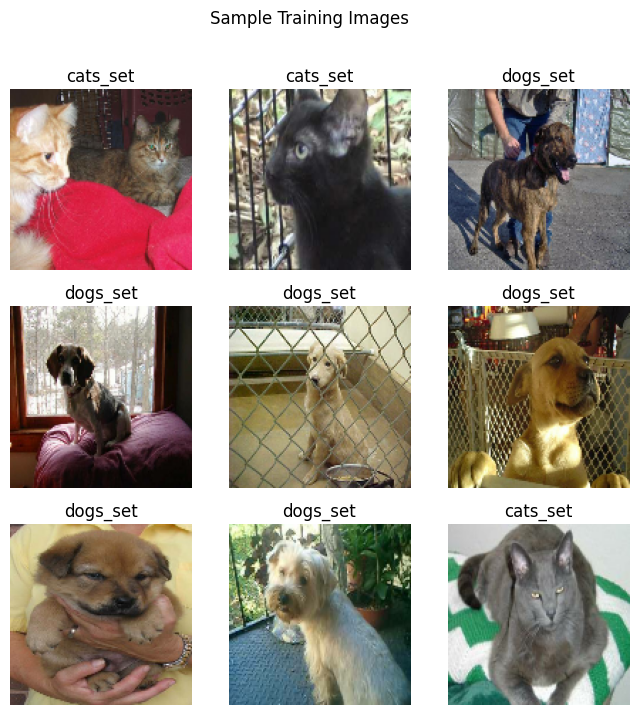

In [17]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [18]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


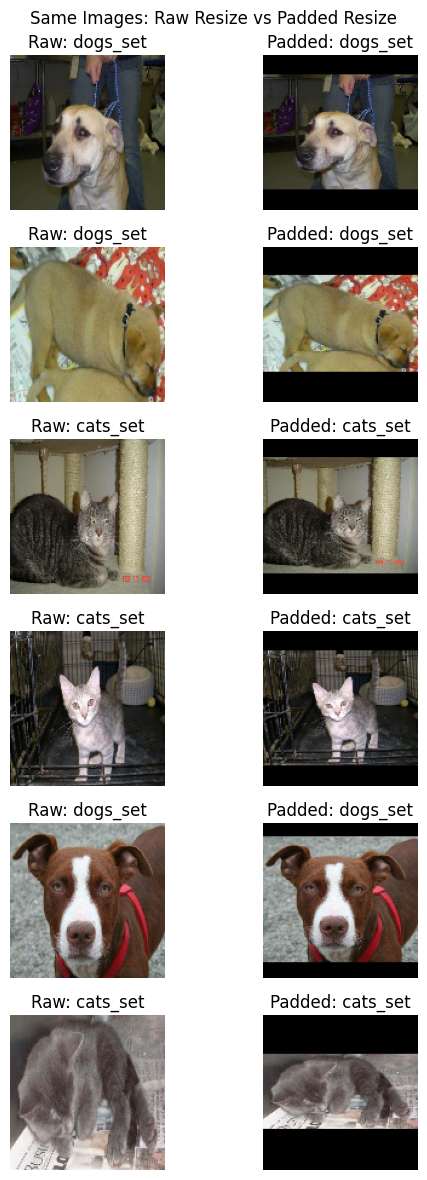

In [19]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [20]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [21]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


### Building the MLP model

In [22]:
# set random seed for reproducibility
tf.random.set_seed(42)  

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.5138 - loss: 3.1094 - val_accuracy: 0.6154 - val_loss: 0.9323
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.5713 - loss: 0.8776 - val_accuracy: 0.5288 - val_loss: 1.0047
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.5962 - loss: 0.7246 - val_accuracy: 0.5288 - val_loss: 0.8751
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.6062 - loss: 0.7937 - val_accuracy: 0.4712 - val_loss: 1.7772
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.5838 - loss: 0.9267 - val_accuracy: 0.5096 - val_loss: 1.2314
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.6675 - loss: 0.7302 - val_accuracy: 0.5288 - val_loss: 0.7663
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.7525 - loss: 0.5154 - val_accuracy: 0.5577 - val_loss: 0.9903
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.7250 - loss: 0.5370 - val_accuracy: 0.

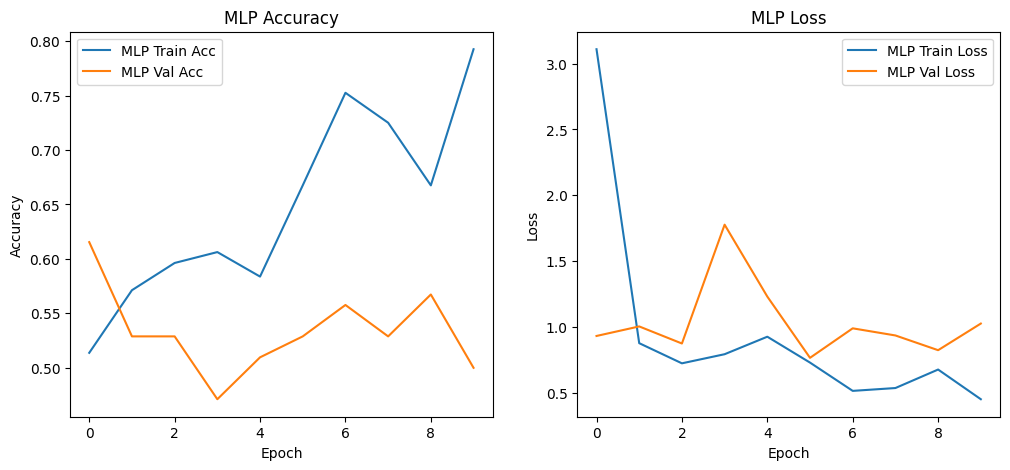

In [24]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [25]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 446ms/step - accuracy: 0.5575 - loss: 0.8529 - val_accuracy: 0.5385 - val_loss: 0.6996
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step - accuracy: 0.6325 - loss: 0.6377 - val_accuracy: 0.5288 - val_loss: 0.7291
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 353ms/step - accuracy: 0.7275 - loss: 0.5484 - val_accuracy: 0.5385 - val_loss: 0.7819
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 337ms/step - accuracy: 0.7875 - loss: 0.4541 - val_accuracy: 0.5673 - val_loss: 0.7200
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - accuracy: 0.8512 - loss: 0.3516 - val_accuracy: 0.6058 - val_loss: 0.8847
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 353ms/step - accuracy: 0.9062 - loss: 0.2509 - val_accuracy: 0.6154 - val_loss: 0.8478
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 351ms/step - accuracy: 0.9525 - loss: 0.1476 - val_accuracy: 0.6442 - val_loss: 0.9120
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 360ms/step - accuracy: 0.9837 - loss: 0.0826 - val_accu

### Visualizing CNN performance

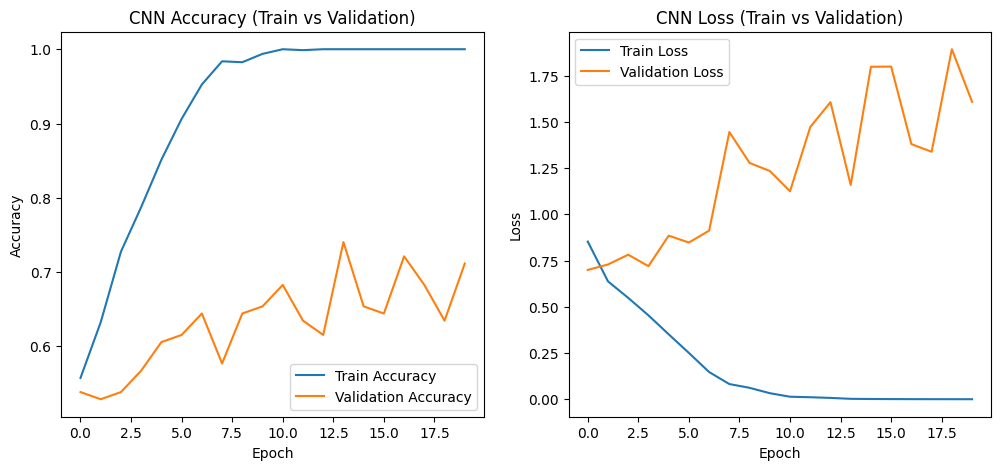

In [26]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [27]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)                   

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.5562 - loss: 0.8056 - val_accuracy: 0.5865 - val_loss: 0.6808
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.6037 - loss: 0.6644 - val_accuracy: 0.4615 - val_loss: 0.7345
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.6338 - loss: 0.6296 - val_accuracy: 0.5865 - val_loss: 0.6820
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.6875 - loss: 0.5757 - val_accuracy: 0.5673 - val_loss: 0.6960
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.7613 - loss: 0.4900 - val_accuracy: 0.5962 - val_loss: 0.6731
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.8263 - loss: 0.4009 - val_accuracy: 0.5577 - val_loss: 0.7967
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 384ms/step - accuracy: 0.8700 - loss: 0.3017 - val_accuracy: 0.6058 - val_loss: 0.7584
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 425ms/step - accuracy: 0.9513 - loss: 0.1777 - val_accuracy: 0

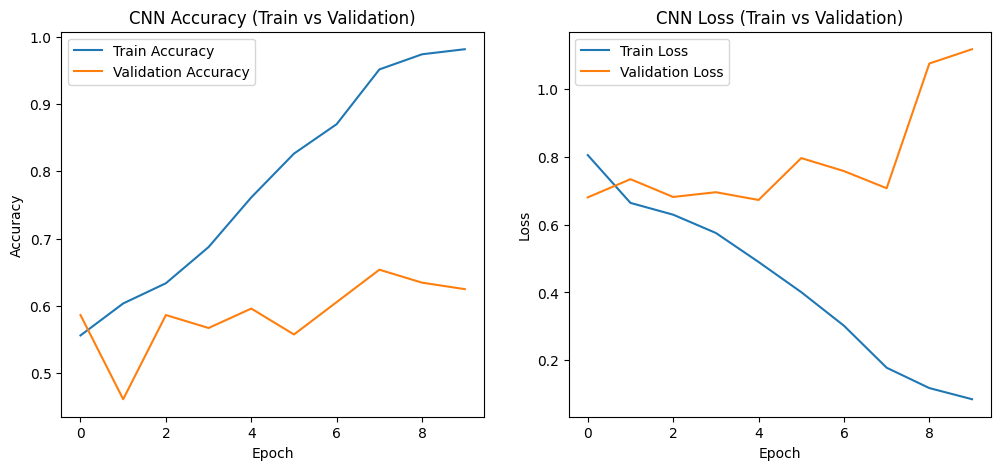

In [28]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [29]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.5113 - loss: 1.0597 - val_accuracy: 0.5865 - val_loss: 0.6894
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 365ms/step - accuracy: 0.5450 - loss: 0.6908 - val_accuracy: 0.5385 - val_loss: 0.6910
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 874ms/step - accuracy: 0.5875 - loss: 0.6777 - val_accuracy: 0.6154 - val_loss: 0.6629
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 497ms/step - accuracy: 0.5900 - loss: 0.6734 - val_accuracy: 0.5962 - val_loss: 0.6685
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 414ms/step - accuracy: 0.5975 - loss: 0.6631 - val_accuracy: 0.5481 - val_loss: 0.6910
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 433ms/step - accuracy: 0.6375 - loss: 0.6496 - val_accuracy: 0.6250 - val_loss: 0.6765
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.6363 - loss: 0.6319 - val_accuracy: 0.5769 - val_loss: 0.7034
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 343ms/step - accuracy: 0.6725 - loss: 0.6030 - val_accura

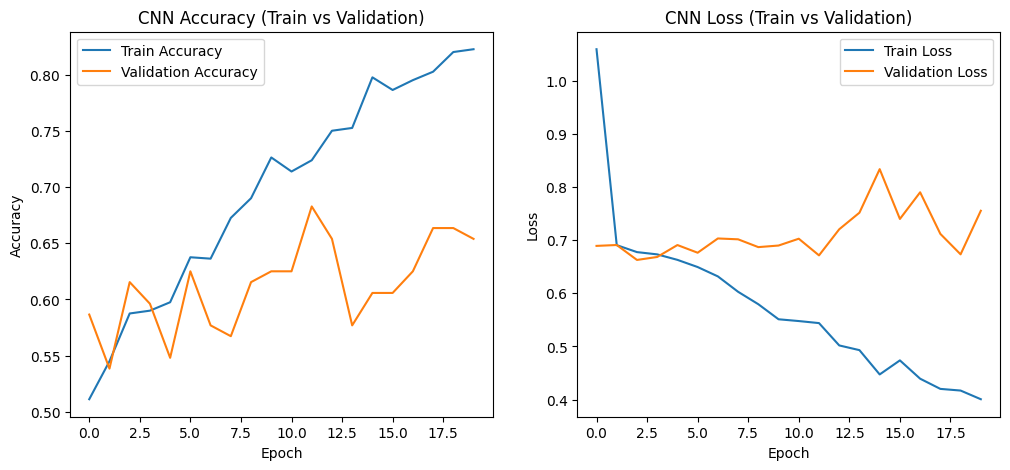

In [30]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [31]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.5525 - loss: 0.7673 - val_accuracy: 0.5096 - val_loss: 0.6922
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 381ms/step - accuracy: 0.5950 - loss: 0.6645 - val_accuracy: 0.5288 - val_loss: 0.7056
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 324ms/step - accuracy: 0.6413 - loss: 0.6445 - val_accuracy: 0.5865 - val_loss: 0.7041
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 0.6862 - loss: 0.6086 - val_accuracy: 0.6154 - val_loss: 0.7298
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 284ms/step - accuracy: 0.7063 - loss: 0.5778 - val_accuracy: 0.5865 - val_loss: 0.7907
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 291ms/step - accuracy: 0.7350 - loss: 0.5328 - val_accuracy: 0.5385 - val_loss: 0.7021
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4688 - loss: 0.6932
Augmented CNN test accuracy: 0.4688


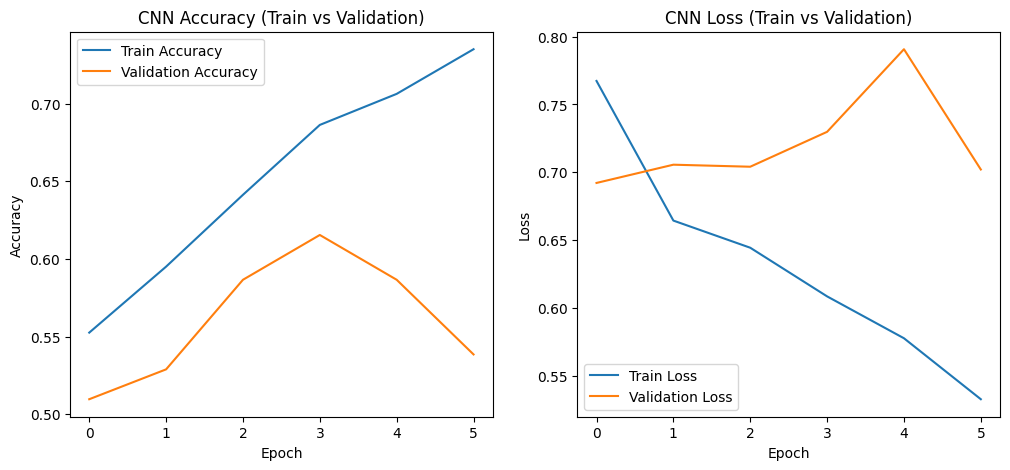

In [32]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

In [33]:
# move model runner into function + store results from each experiment for easier plotting
results = []
histories = {}

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

def run_model(model, model_name, epochs=20):
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds_padded,
        validation_data=val_ds_padded,
        epochs=epochs,
        callbacks=[early_stop]
    )

    test_loss, test_acc = model.evaluate(test_ds_padded)

    results.append({
        "Model": model_name,
        "Epochs Run": len(history.history["loss"]),
        "Final Training Accuracy": history.history["accuracy"][-1],
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Test Accuracy": test_acc,
        "Test Loss": test_loss
    })

    histories[model_name] = history
    plot_history(history, model_name)

    return history

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 488ms/step - accuracy: 0.5612 - loss: 0.7443 - val_accuracy: 0.5192 - val_loss: 0.6909
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 315ms/step - accuracy: 0.6037 - loss: 0.6570 - val_accuracy: 0.5481 - val_loss: 0.7389
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 418ms/step - accuracy: 0.6963 - loss: 0.5880 - val_accuracy: 0.5962 - val_loss: 0.6755
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 409ms/step - accuracy: 0.7563 - loss: 0.5154 - val_accuracy: 0.5865 - val_loss: 0.7695
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 436ms/step - accuracy: 0.7725 - loss: 0.4788 - val_accuracy: 0.5385 - val_loss: 0.7521
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - accuracy: 0.8400 - loss: 0.3726 - val_accuracy: 0.6154 - val_loss: 0.8014
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 438ms/step - accuracy: 0.8975 - loss: 0.2749 - val_accuracy: 0.5769 - val_loss: 1.0296
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 0.5625 - loss: 0.6934


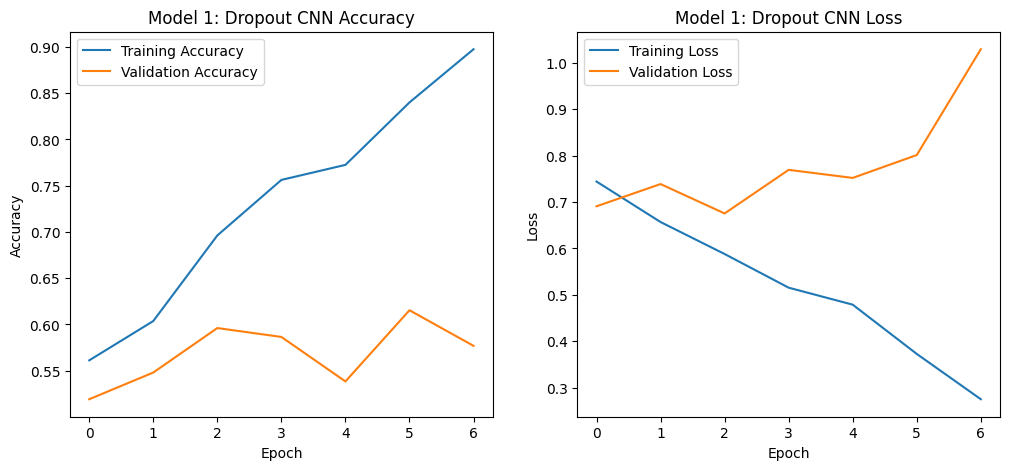

In [34]:
# Your code 

# dropout
model_1 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

history_1 = run_model(model_1, "Model 1: Dropout CNN")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 942ms/step - accuracy: 0.5088 - loss: 0.7060 - val_accuracy: 0.5577 - val_loss: 0.6859
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 599ms/step - accuracy: 0.5600 - loss: 0.6794 - val_accuracy: 0.5000 - val_loss: 0.7343
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 503ms/step - accuracy: 0.5900 - loss: 0.6733 - val_accuracy: 0.4904 - val_loss: 0.7161
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 453ms/step - accuracy: 0.5962 - loss: 0.6619 - val_accuracy: 0.5288 - val_loss: 0.7120
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 570ms/step - accuracy: 0.6325 - loss: 0.6560 - val_accuracy: 0.5962 - val_loss: 0.6856
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 761ms/step - accuracy: 0.6388 - loss: 0.6196 - val_accuracy: 0.6154 - val_loss: 0.6899
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 482ms/step - accuracy: 0.6050 - loss: 0.6518 - val_accuracy: 0.5577 - val_loss: 0.6736
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 451ms/step - accuracy: 0.6525 - loss: 0.6140 - val_accu

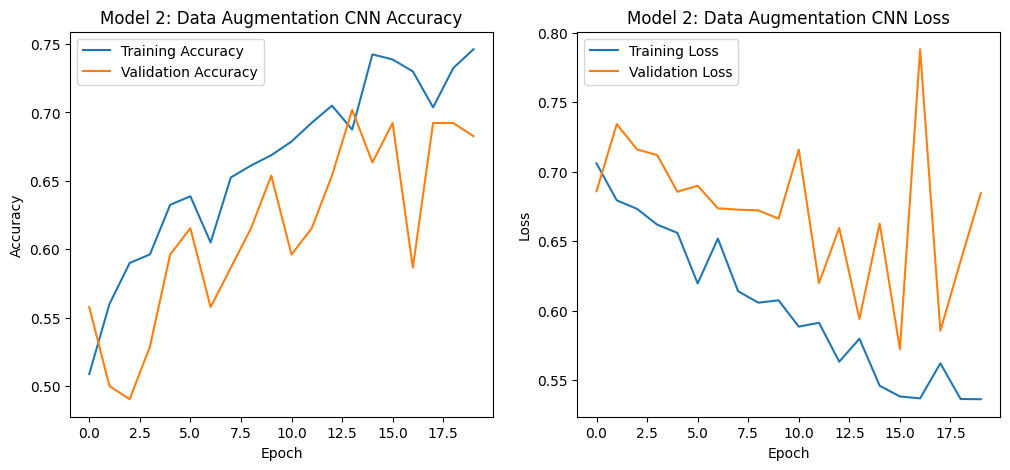

In [35]:
# Your code here

# data augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

model_2 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

history_2 = run_model(model_2, "Model 2: Data Augmentation CNN")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 848ms/step - accuracy: 0.5225 - loss: 2.9837 - val_accuracy: 0.5288 - val_loss: 0.6922
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 817ms/step - accuracy: 0.5850 - loss: 0.6794 - val_accuracy: 0.5673 - val_loss: 0.6913
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 813ms/step - accuracy: 0.5800 - loss: 0.6686 - val_accuracy: 0.4904 - val_loss: 0.6978
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 600ms/step - accuracy: 0.6037 - loss: 0.6498 - val_accuracy: 0.5673 - val_loss: 0.6961
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 780ms/step - accuracy: 0.5663 - loss: 0.6724 - val_accuracy: 0.4904 - val_loss: 0.7005
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 715ms/step - accuracy: 0.6050 - loss: 0.6453 - val_accuracy: 0.5096 - val_loss: 0.7088
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.5312 - loss: 0.6903


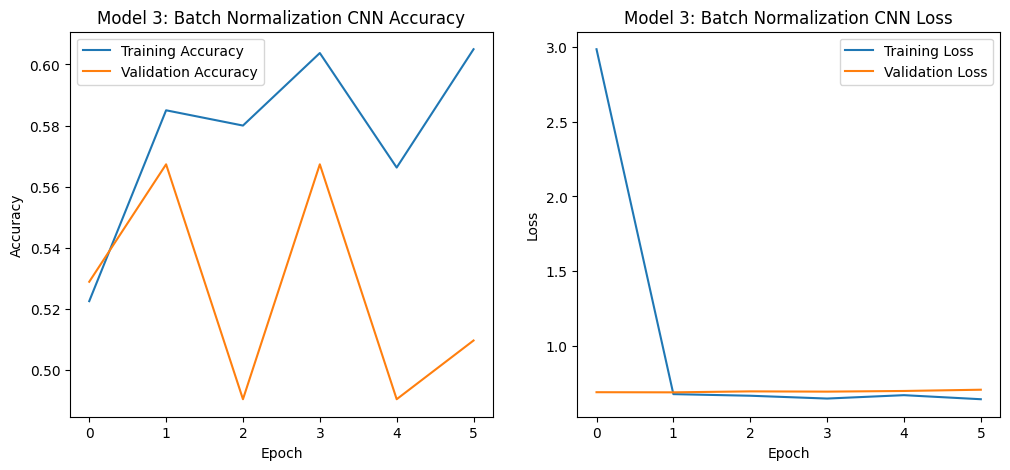

In [36]:
# your code here
model_3 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

history_3 = run_model(model_3, "Model 3: Batch Normalization CNN")

### What seemed to help model performance most in your experiments?

| Model | Main Change | Best Validation Accuracy | Test Accuracy | Main Observation |
|---|---|---:|---:|---|
| Model 1 | Dropout | 0.615 | 0.563 | Overfit strongly |
| Model 2 | Data augmentation + deeper CNN | 0.702 | 0.750 | Best generalization |
| Model 3 | Batch normalization | 0.567 | 0.531 | Did not improve performance |

- Model 1 added dropout to a basic CNN. This model learned the training data well, reaching about 90% training accuracy, but the validation accuracy stayed much lower and the validation loss increased, suggesting overfitting.

- **Model 2** added data augmentation, an additional convolutional layer, and stronger dropout. This was the best model overall. It ended with the highest validation accuracy, about 70%, and had the best test accuracy, about 75%. The training and validation accuracies were also closer together than Model 1, suggesting better generalization.

- Model 3 used batch normalization with dropout. This model did not perform as well. Accuracy was quite poor, random guessing-like, and early stopping ended training after only a few epochs. So, batch normalization did not improve performance.

Overall, **data augmentation was the most helpful change**. The main tradeoff was that larger or deeper models could learn more patterns, but they also overfit more easily on this small dataset. Data augmentation slowed training somewhat, but it improved generalization the most. The models can memorize the training images, but validation accuracy is lower because the model doesn't have enough data to learn general cat and dog features.